# Adverse selection and markouts

I use fixed seeds here so the numerical examples remain comparable when the implementation changes.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
ROOT = Path.cwd() if (Path.cwd()/"src").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT/"src"))
pd.set_option("display.max_columns", 30)

I use a latent signal to create adverse selection in a controlled way, then examine markouts at several horizons to see whether the initial execution edge survives.

In [2]:
curve=pd.read_csv(ROOT/"outputs/tables/markout_curve_toxic_fixed.csv")
curve

,horizon_steps,markout_per_unit,price_component_per_unit,total_quantity
0,1,-0.012512,-0.068182,108.0
1,5,-0.016326,-0.072018,105.0
2,20,-0.005271,-0.061056,103.0
3,50,-0.028696,-0.084353,90.0


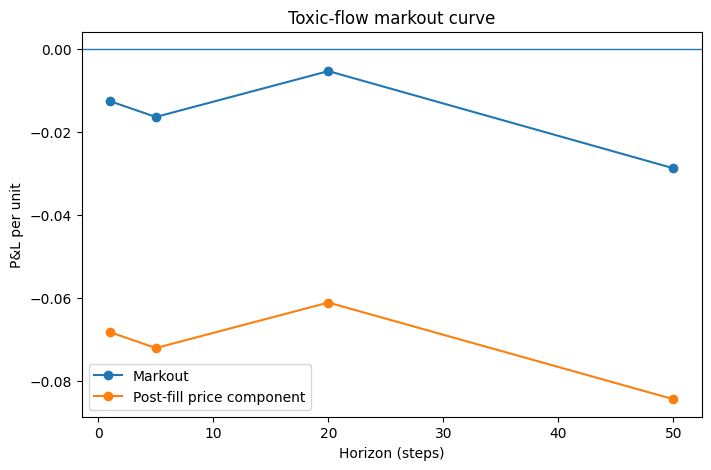

In [3]:
plt.figure(figsize=(8,5)); plt.plot(curve.horizon_steps,curve.markout_per_unit,marker="o",label="Markout"); plt.plot(curve.horizon_steps,curve.price_component_per_unit,marker="o",label="Post-fill price component"); plt.axhline(0,linewidth=1); plt.xlabel("Horizon (steps)"); plt.ylabel("P&L per unit"); plt.legend(); plt.title("Toxic-flow markout curve"); plt.show()

In [4]:
summary=pd.read_csv(ROOT/"outputs/tables/strategy_summary.csv")
summary[summary.scenario=="toxic"][["strategy","mean_terminal_pnl","pnl_5_percentile","mean_markout_per_unit","mean_toxic_fraction"]]

,strategy,mean_terminal_pnl,pnl_5_percentile,mean_markout_per_unit,mean_toxic_fraction
25,fixed,-2.863340,-21.858940,-0.002809,0.815301
26,full_adaptive,1.655407,-5.066106,0.072351,0.833321
27,full_risk,1.742099,-5.066106,0.072112,0.834135
28,inventory,-1.212906,-11.056972,-0.006317,0.813452
29,inventory_volatility,0.977489,-6.407537,0.048769,0.807224
